In [7]:
from gymnasium.wrappers import TimeLimit

from envs.contextual_env import  CtxDictWrapper, ctx_visibility, exp_group, GMMCtxEnvWrapper, SquashedGMMCtxEnvWrapper

from envs.brax.half_cheetah_ctx import HalfcheetahCTX
import numpy as np

ctx_mode=0
max_steps=1000

ctx_lb = np.array([1, -np.inf, -np.inf,-np.inf, 0., 0.1])
ctx_ub = np.array([np.inf, -.1, np.inf, np.inf, np.inf, np.inf])

ctx_dim = 6


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
env.reset()


array([0.93627213, 0.96445382, 0.90980909, 0.8585354 , 0.24197645,
       0.08617132, 0.23471302, 0.95398093])

In [8]:
x=env.observation_space.sample()
x[0]=-5
np.clip(x, a_min=env.observation_space.low, a_max=env.observation_space.high)

array([-3.1415927e+00, -8.8086259e-01,  3.6190587e-01,  3.9541817e+00,
        2.7043056e+00, -1.0480536e+00, -2.0399902e+00,  2.8051736e+00,
        4.4374913e-01, -2.0022821e+00, -9.3904853e-01, -8.4488846e-02,
        3.5672104e+00,  4.0970688e+00,  6.9731408e-01,  5.9410030e-01,
       -2.3235103e-01,  1.3888115e-03,  2.3957383e-02, -2.3082334e-01,
       -9.6545434e-01,  4.0373638e-01,  6.6884053e-01,  4.9874973e-01],
      dtype=float32)

In [10]:

config={'target_mean' : np.array([25000.0, -9.8, 0.77459666924, -0.009999999776482582, 20, 9.457333]),
                            'target_var': np.square([100, 0.5, .1, .001, 1., .5]),
                            'init_mean':np.array([25000.0, -9.8, 0.77459666924, -0.009999999776482582, 20, 9.457333]),
                            'init_var': np.square([100, 0.5, .1, .001, 1., .5]),
                            'prior': None}
env_creator = lambda config: SquashedGMMCtxEnvWrapper(CtxDictWrapper(
                TimeLimit(HalfcheetahCTX(), max_episode_steps=max_steps)),
                ctx_lb=ctx_lb, ctx_ub=ctx_ub, ctx_mode=ctx_mode, **config)
env=env_creator(config=config)

TypeError: object of type 'float' has no len()

In [ ]:
config={'target_mean' : np.array([0.3375 * np.pi, 0.85, 2.5]),
                            'target_var': np.array([0.2 * np.pi, 0.15, .6]),
                            'init_mean':np.array([0.68, 0.9, 0.1]),
                            'init_var': np.array([1e-3, 1e-3, 0.001]),
                            'prior': None}

In [43]:
samples=np.random.normal(0.3375 * np.pi,( 0.2 * np.pi)**.5, 1000)

(sum(samples>.5*np.pi)+sum(samples<.1*np.pi))/1000

0.409

In [60]:
lb=0
ub=12
mu=5
std=3
def squashed_sim(lb=0, ub=12, mu=5, std=3):
    samples=np.random.normal(mu,std, 1000)

    samples_clipped=np.clip(samples,a_min=lb, a_max=ub)
    print(np.mean(samples_clipped),np.std(samples_clipped),(sum(samples>ub)+sum(samples<lb))/1000)

    samples=np.random.normal(0,1, 1000)
        # gaussian_samples = np.random.normal(loc=mean, scale=std_dev, size=num_samples)

        # 2. Apply the tanh squashing function
    squashed_samples = std*np.tanh(samples)+mu

    samples_clipped=np.clip(squashed_samples,a_min=lb, a_max=ub)
    print(np.mean(samples_clipped),np.std(samples_clipped),(sum(squashed_samples>ub)+sum(squashed_samples<lb))/1000)
    samples=std*samples+mu
    samples_clipped= lb+ (np.tanh(samples)+1)*(ub-lb)/2

    print(np.mean(samples_clipped),np.std(samples_clipped),(sum(samples>ub)+sum(samples<lb))/1000)


In [102]:
x=np.random.triangular(np.array([0,1]), np.array([2,3]), np.array([3,4]))


In [104]:
x[x>np.array([1,3])]

array([1.39630455])

In [105]:
x

array([1.39630455, 2.70067477])

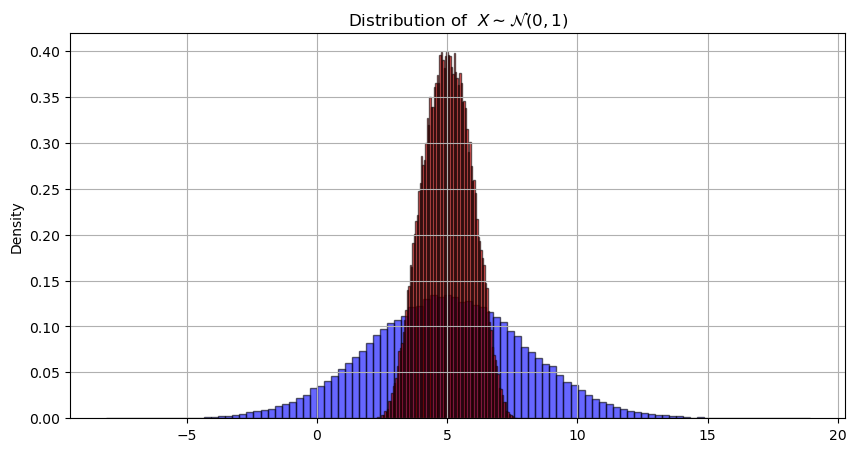

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Sample X ~ N(0,1)
x = np.random.uniform(0, 1, 100000)

# Transform Y = tanh(X)
y =             np.exp^()
# *(ub+lb)/2
x2=np.random.normal(mu, std, 100000)
plt.figure(figsize=(10, 5))
plt.hist(x2, bins=100, density=True, alpha=0.6, color='blue', edgecolor='black')
plt.hist(y, bins=100, density=True, alpha=0.6, color='red', edgecolor='black')

plt.title("Distribution of  $X \\sim \\mathcal{N}(0,1)$")
# plt.xlabel("Y")
plt.ylabel("Density")
plt.grid(True)
plt.show()
# Plot the result
# plt.figure(figsize=(10, 5))
# plt.title("Distribution of $Y = \\tanh(X)$ where $X \\sim \\mathcal{N}(0,1)$")


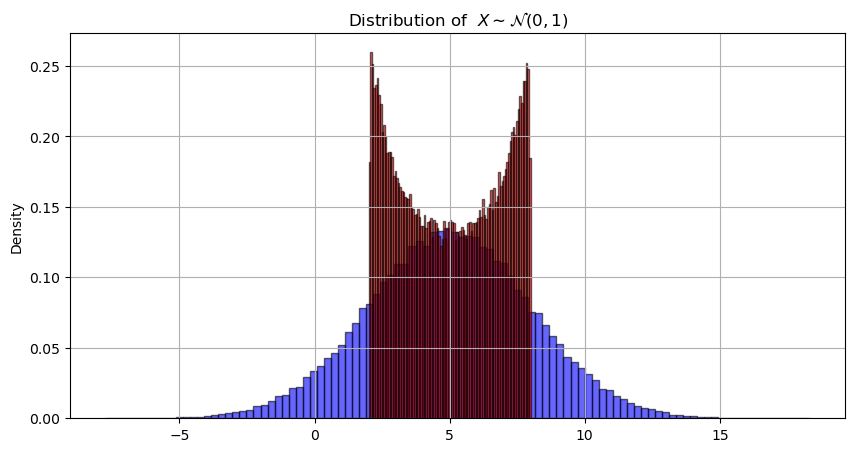

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Sample X ~ N(0,1)
x = np.random.normal(0, 1, 100000)

# Transform Y = tanh(X)
y = std*np.tanh(x)+mu
x2=np.random.normal(mu, std, 100000)
plt.figure(figsize=(10, 5))
plt.hist(x2, bins=100, density=True, alpha=0.6, color='blue', edgecolor='black')
plt.hist(y, bins=100, density=True, alpha=0.6, color='red', edgecolor='black')

plt.title("Distribution of  $X \\sim \\mathcal{N}(0,1)$")
# plt.xlabel("Y")
plt.ylabel("Density")
plt.grid(True)
plt.show()

(5, 1)


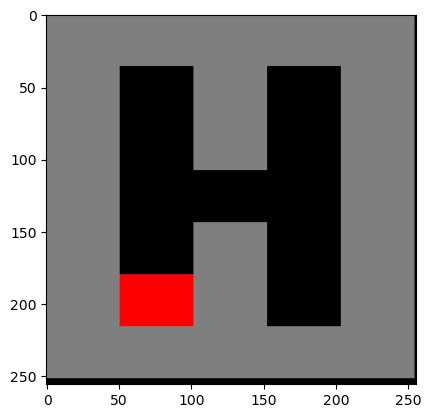

In [22]:
print(env.agent_state)
env.render()

In [18]:
import gymnasium as gym
env = gym.make("LunarLander-v2", continuous=False, gravity=-10.0,
               enable_wind=True, wind_power=15.0, turbulence_power=1.5)
env.spec

EnvSpec(id='LunarLander-v2', entry_point='gymnasium.envs.box2d.lunar_lander:LunarLander', reward_threshold=200, nondeterministic=False, max_episode_steps=1000, order_enforce=True, autoreset=False, disable_env_checker=False, apply_api_compatibility=False, kwargs={'continuous': False, 'gravity': -10.0, 'enable_wind': True, 'wind_power': 15.0, 'turbulence_power': 1.5}, namespace=None, name='LunarLander', version=2, additional_wrappers=(), vector_entry_point=None)

In [24]:
from envs.lunar_lander import LunarLanderCtx, LunarLander


env= LunarLander(gravity= -10.0,
            wind_power = 15.0,
            turbulence_power = 1.5,)

print(env.reset())

# print(env.get_task())

# env.set_task(np.array([-8,12,1.], dtype=np.float32))
# print(env.get_task())

(array([-0.00768404,  1.4101768 , -0.778321  , -0.03306871,  0.00891063,
        0.17630121,  0.        ,  0.        ], dtype=float32), {})


In [23]:
a=np.array([1,2,3
            ])
float(a)

TypeError: only size-1 arrays can be converted to Python scalars

In [10]:
from deep_sprl.environments. contextual_ball_catching import ContextualBallCatching

In [11]:
env = ContextualBallCatching()

TypeError: __init__() missing 1 required positional argument: 'observation_space'

In [8]:
env.reset()
env.render()

AttributeError: Unexpected mode: None, expected modes: human, rgb_array, or depth_array